# Assignment 4: Decision Tree
## Description:
The objectives of this assignment are to help students:
- Build Decision Tree using different types of features such continuous, ordinal, etc.
- Apply pruning approach.
- Evaluate, analyze and interpret the result of Decision Tree model.
- Recognize and explain overfitting in a trained model.
- Use cross-validation to tune a hyperparameter in a principled way

## Group 4 Members:
- Xander Boosinger
- Zach Rojas
- Kyle Nguyen


### Part 1: Data Preprocessing

* #### Initial Exploration
1.  Load the dataset. Print the shape and the first 5 rows.

In [1]:
import pandas as pandas
import seaborn as seaborn
import matplotlib.pyplot as pyplot
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import ConfusionMatrixDisplay
import time

df = pandas.read_excel('titanic.xlsx')

#Drop the passenger ID; no useful data in it.
df = df.drop(["PassengerId"], axis=1)

pandas.set_option('display.max_colwidth', None)
pandas.set_option('display.width'
, 1000)
pandas.set_option('display.max_columns', None)

print("Dimensions:")
print(df.shape)
print("")

print("Head:")
print(df.head(5))
print("")

Dimensions:
(891, 11)

Head:
   Survived  Pclass                 Name     Sex   Age  SibSp  Parch           Ticket      Fare Cabin Embarked
0         1       2   Brown, Miss. Mabel  female  61.0      0      1           797787    7.6093   NaN        S
1         0       3  Young, Miss. Nellie  female  20.9      1      1           705364    3.1700  D119        S
2         0       3    Allen, Mr. George    male  40.5      0      0           542486    4.6967   NaN        S
3         0       3    King, Miss. Edith  female   NaN      0      0           920156   44.1734   NaN        S
4         0       1   Wilson, Mr. Thomas    male  48.6      0      0  STON/O2. 480198  243.1897   NaN        S



2. Print the data types and check for missing values in every column. In a 
markdown cell, report which columns have missing values and how many are missing in 
each. 

In [2]:
print("Types:")
print(df.dtypes)
print("")

print("Null Value Counts:")
print(df.isnull().sum())
print("")

Types:
Survived      int64
Pclass        int64
Name         object
Sex          object
Age         float64
SibSp         int64
Parch         int64
Ticket       object
Fare        float64
Cabin        object
Embarked     object
dtype: object

Null Value Counts:
Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64



Null Value Counts:
PassengerID:      0

Survived:         0

Pclass:           0

Name:             0

Sex:              0

Age:            177

SibSp:            0

Parch:            0

Ticket:           0

Fare:             0

Cabin:          687

Embarked:         2

3. For each column that has missing values, decide how to handle it:
    1) fill it in 
    2) or drop the column entirely. In a markdown cell, explain why you chose each strategy.  

In [3]:
df = df.drop(["Cabin"], axis=1)
df = df.fillna(df.median(numeric_only=True))
df = df.fillna("S")

I decided to drop Cabin, because although I think this feature *would* be useful, in theory, there's not much I can do when 70% of the data is just missing. The median, realistically speaking, would be NaN!

Age is being median imputed because it's a pretty reasonable statistic to take an average/median of, and for the 600 records with an age marked, I expect it to have a legitimate correlation with survival.

Embarked is being tentatively filled with "S", as while it does seem like a relatively meaningless feature, it also only has two missing values. I may just not know about some correlation between boarding order and cabin location, so it gets to stay. I picked "S" because that was the origin port.

4. Verify that no missing values remain. Print the missing value counts after your 
changes to confirm. 

In [4]:
print("Null Value Counts:")
print(df.isnull().sum())
print("")

Null Value Counts:
Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Ticket      0
Fare        0
Embarked    0
dtype: int64



* #### Encode Categorical Features 
1.  Identify the string columns that can be meaningfully encoded. Apply the 
appropriate encoding method to each: 
    1) Binary columns with exactly two values to convert to 0/1.
    2) Columns with more than two categories to create one-hot encoded columns. 

In [5]:
df = pandas.get_dummies(df, prefix=['Embarked'], columns=['Embarked'], dtype=int)

df["Sex"] = df["Sex"].replace(["male", "female"], ["0", "1"]).astype(int)

print(df)

     Survived  Pclass                 Name  Sex   Age  SibSp  Parch           Ticket      Fare  Embarked_C  Embarked_Q  Embarked_S
0           1       2   Brown, Miss. Mabel    1  61.0      0      1           797787    7.6093           0           0           1
1           0       3  Young, Miss. Nellie    1  20.9      1      1           705364    3.1700           0           0           1
2           0       3    Allen, Mr. George    0  40.5      0      0           542486    4.6967           0           0           1
3           0       3    King, Miss. Edith    1  30.0      0      0           920156   44.1734           0           0           1
4           0       1   Wilson, Mr. Thomas    0  48.6      0      0  STON/O2. 480198  243.1897           0           0           1
..        ...     ...                  ...  ...   ...    ...    ...              ...       ...         ...         ...         ...
886         0       3    Smith, Mr. Walter    0  22.4      0      0           78134

2. In a markdown cell, explain which method you used for each column and why 
one-hot encoding is preferred over label encoding for a nominal column like Embarked. 

I used one-hot encoding for Embarked because label encoding can lead to the column being mistakenly treated as continuous data, rather than what it truly is; i.e., the tree will split on "Embarked" < 1.5, or something along those lines. What we actually want is one hot encoding, so that the tree can split on each embarking location separately.

For the sex column, it seems pretty straightforward how one would correlate male/female with 0/1, and that the tree will easily be able to split on that binary data.

3. Drop the columns that cannot be meaningfully encoded. In a markdown cell, 
explain the reason for dropping each one. It might be different reasons even if the action 
is the same. 

In [6]:
df = df.drop(["Name", "Ticket"], axis=1)

Name and Ticket are being dropped because both names and tickets are relatively unique, so there's effectively no generalizable data to be had there no matter what; it's possible tickets could be somewhat related to the cabin one gets, but I find that unlikely, particularly since the assignment notes state that it has "no consistent structure".

* #### Heatmap Visualization 
1.  Generate a correlation heatmap for all features in your DataFrame (including 
Survived). Use seaborn.heatmap() with annot=True. Make the figure large enough to read 
clearly. 

Heatmap Correlation


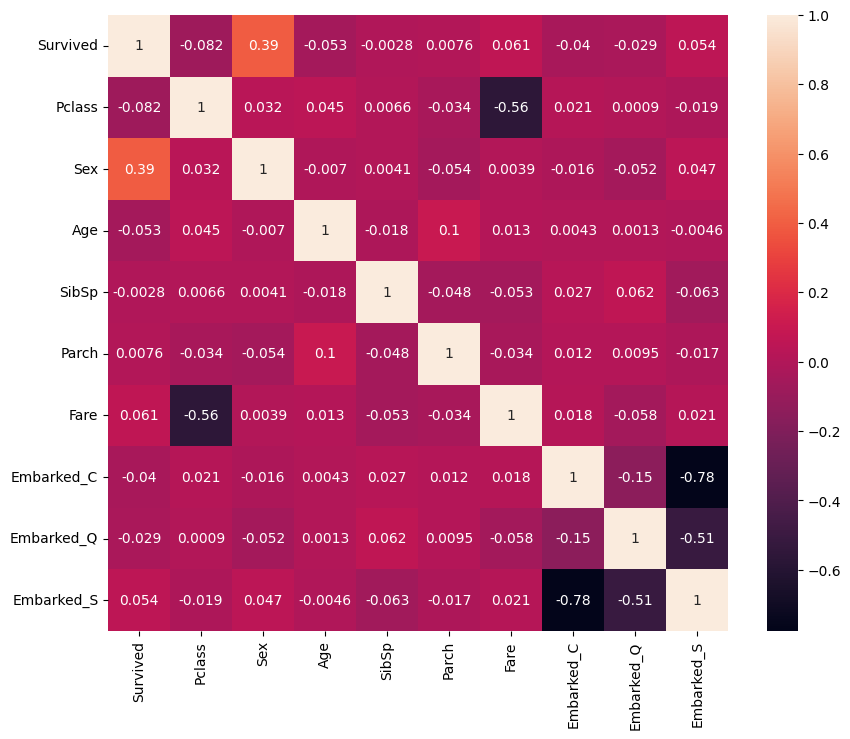

In [7]:
print("Heatmap Correlation")
pyplot.figure(figsize=(10, 8))
correlationMatrix = df.corr()
seaborn.heatmap(correlationMatrix, annot=True)
pyplot.show()
print("")

2.  In a markdown cell, answer the following three questions, you must reference 
specific column names and numeric correlation values from your heatmap: 
    1) Report the two largest absolute correlations with Survived, including their exact 
values and signs. What does the sign of each tell you about the relationship with 
survival? 
    2) Do you observe any two features that are strongly correlated with each other rather 
than with Survived? Report the pair and the correlation value. What might explain 
this? 

A. Sex and PClass (Passenger Class) had the highest absolute correlations with Survived, where Sex/Survived being positive meaning that when Sex increases (male->female), the rate of survival also increases. PClass/Survived being negative means that when PClass increases (1stClass->...->3rdClass), the rate of survival decreases.

B. The Embarkeds all have relatively high absolute correlations, because they were one hot encoded; this is because when one is true, the others are always false, although it's not perfectly correlated, because when one is false, the others may or may not also be false.
More notably, Fare and PClass have a high absolute correlation, since the passenger class would naturally scale with the passenger fare.

* #### Prepare Features and Split 
1.  Split your data into training (80%) and testing (20%) sets using stratify on the 
target variable and random_state=42. 

In [8]:
features = df.drop(columns=["Survived"])
labels = df["Survived"]

#Split the data into training and testing feature tables, and training and testing label arrays
features_train, features_test, labels_train, labels_test = train_test_split(
    features,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

2. Print the shape of all four arrays (X_train, X_test, y_train, y_test). 

In [9]:
print("Split Data:")
print(features_train.shape)
print(features_test.shape)
print(labels_train.shape)
print(labels_test.shape)
print("")

Split Data:
(712, 9)
(179, 9)
(712,)
(179,)



3. In a markdown cell, verify that the survival rate is approximately the same in
both splits. Why does stratification matter here? 

In [10]:
print("Value Counts:")
print("")
print(labels_train.value_counts())
print("Survival Ratio:", labels_train.value_counts()[0] /  labels_train.value_counts()[1])
print("")
print(labels_test.value_counts())
print("Survival Ratio:", labels_test.value_counts()[0] /  labels_test.value_counts()[1])
print("")

Value Counts:

Survived
0    476
1    236
Name: count, dtype: int64
Survival Ratio: 2.016949152542373

Survived
0    120
1     59
Name: count, dtype: int64
Survival Ratio: 2.0338983050847457



The survival ratio is effectively the same for both sets, so the stratification worked nicely. That matters so we can ensure a relatively even distribution of records between each set, since it would clearly be an issue if we trained on just non-survivors, but then tested on only the survivors. There'd be basically no information gain in that case, and so we stratify for consistency.

4. Verify that all features are numerical by printing X_train.dtypes. In a 
markdown cell, confirm that no string or Boolean columns remain. If any do, fix them 
now and explain what you have changed. 

In [11]:
print("Types:")
print(features_train.dtypes)
print("")

Types:
Pclass          int64
Sex             int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Embarked_C      int64
Embarked_Q      int64
Embarked_S      int64
dtype: object



As can be seen above, all of the columns remaining are of numeric types (float or int).

### Part 2: Build Decision Tree

* #### Train an Unpruned Tree 
1. Train a DecisionTreeClassifier with criterion='entropy', random_state=42, and 
no other constraints (default parameters).  

In [12]:
classifier = DecisionTreeClassifier(criterion='entropy', random_state=42).fit(features_train, labels_train)

2.  Report the training accuracy and testing accuracy. Print both values clearly. 

In [13]:
# Print out the classifier training and test accuracy
print("Accuracy for training data: ", classifier.score(features_train, labels_train))
print("Accuracy for testing data: ", classifier.score(features_test, labels_test))

Accuracy for training data:  0.9985955056179775
Accuracy for testing data:  0.7541899441340782


* #### Analyze the Overfitting
1. In a markdown cell, compare the training and testing accuracy. What do you 
observe? Is the model overfitting? How can you tell?

The accuracy of the model on the training dataset is about 99.8% while the accuracy of the model on the test dataset is only about 75.4%. This means that the model is overfitting on the training data because it is very good at classifying data it has already seen, but it has a high error when new data is inputted. 

2) Print the depth of your unpruned tree using tree.get_depth() and the total 
number of leaves using tree.get_n_leaves(). In a markdown cell, comment on whether 
these numbers seem reasonable for a dataset of this size. 

In [14]:
print("Tree depth: ", classifier.get_depth())
print("Number of leaves: ", classifier.get_n_leaves())

Tree depth:  26
Number of leaves:  130


These numbers do seem a bit large for a dataset of this size. The tree has a large depth which splits the data many times. Additionally, there are a large number of leaf nodes, which can explain why the model is overfitted on the data.

3) Create a plot showing training accuracy vs. testing accuracy for max_depth 
values from 1 to 20. Use a line plot with two clearly labeled lines, axis labels, a legend, 
and a title.

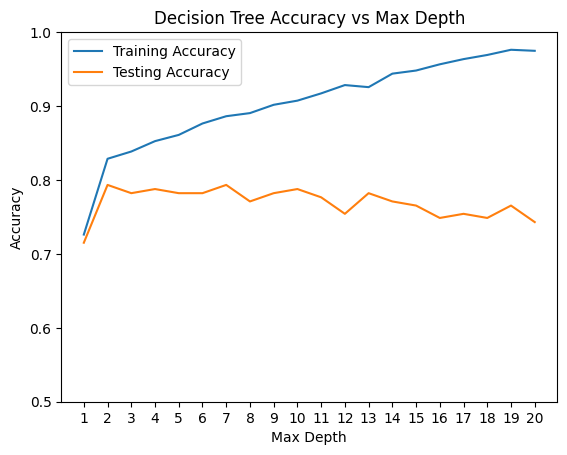

In [15]:
# Train the model using depth values from 1 to 20
training_accuracies = []
testing_accuracies = []
for i in range(1, 21):
    tree = DecisionTreeClassifier(criterion='entropy', random_state=42, max_depth=i).fit(features_train, labels_train)
    training_accuracies.append(tree.score(features_train, labels_train))
    testing_accuracies.append(tree.score(features_test, labels_test))
# Create the plot

pyplot.plot(range(1, 21), training_accuracies, label='Training Accuracy')
pyplot.plot(range(1, 21), testing_accuracies, label='Testing Accuracy')
pyplot.xlabel('Max Depth')
pyplot.ylabel('Accuracy')
pyplot.ylim(0.5, 1)
pyplot.xticks(range(1, 21, 1))
pyplot.title('Decision Tree Accuracy vs Max Depth')
pyplot.legend()
pyplot.show()


4) In a markdown cell below the plot, describe what pattern you observe and at 
what depth the gap between training and testing accuracy starts to widen noticeably.

From a depth of 1 to 3, the testing accuracy and the training accuracy were very similar. After this, the gap between the training and testing accuracy widens very noticably as the model starts overfitting to the data. Additionally, at around a depth of 13, the gap between the two seems to widen at a faster rate.

5) In a markdown cell: When max_depth=1, the tree is very shallow. Is this 
model more likely to suffer from underfitting or overfitting? What about when 
max_depth=20? Connect your answers to what you see in your plot above.

When the max depth is equal to one, the tree is very shallow and is more likely to suffer from underfitting. With a shallower tree, the model isn't complex enough to accurately predict the data. This is shown in the plot because when the depth of the tree was 1, the training and test accuracy were very similar, but also low. When the depth of the tree increased to 2, the accuracy of both the training and test data increased, which shows that the tree was underfitted. After about a depth of three however, the tree starts to overfit as the training accuracy increases while the test accuracy decreases. 

6. Based on your plot, what range of max_depth values appears to give the best 
balance between training and testing performance? Justify your answer. 

Based on the plot, the range of max_depth values that appears to give the best balance between training and testing performance is a depth between 3 and 7. This is because after a depth of 7, the accuracy of the model on the test data only decreased as the depth increased, while between the depth values of 3 and 7 the accuracy was relatively the same. The accuracy of the training data only continued to increase after a depth value of 7, so this range is the best to get a good balance between the training and testing performance.

* #### Confusion Matrix

1. Generate and display a confusion matrix for the untuned tree on the test set.

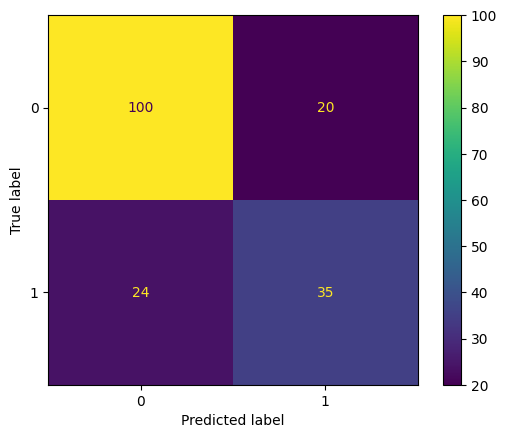

In [16]:
display = ConfusionMatrixDisplay.from_estimator(classifier, features_test, labels_test)

2. In a markdown cell, interpret the confusion matrix: 
    1) How many True Negatives and True Positives did the model produce? 
    2) Which error type is more common, False Positives or False Negatives? 
    3) In the Titanic context, what is the real-world consequence of each error type? 
Which would you consider more costly and why? 

1. The model produced 35 true positives and 100 true negatives
2. There were 24 false negatives and 20 false positives. False negatives were more common than false positives
3. In the context of the Titanic, a false positive would overestimate someone's chance of survival, while a false negative would underestimate someone's chance of survival. In a real-world context, a false negative could lead to not prioritizing someone who might have a low chance of survival, which I think would be more costly than prioritizing someone who already had a good chance to survive.

* #### Effect of Training Sample Size

1) Using your unpruned tree, train the model on increasing fractions of the 
training set: 10%, 25%, 50%, 75%, and 100%. For each fraction, record:
    1) training accuracy
    2) testing accuracy
    3) averaged training time. Create a figure with two subplots: one showing training and testing accuracy vs. training set size, and another 
showing training time vs. training set size.
Label all axes and include legends. 

Training model with 10% of the dataset
Training time:  0.0026910054683685304
Training accuracy:  1.0
Testing accuracy:  0.7486033519553073

Training model with 25% of the dataset
Training time:  0.002484402656555176
Training accuracy:  1.0
Testing accuracy:  0.7653631284916201

Training model with 50% of the dataset
Training time:  0.002985802888870239
Training accuracy:  1.0
Testing accuracy:  0.770949720670391

Training model with 75% of the dataset
Training time:  0.0034933066368103027
Training accuracy:  0.99812734082397
Testing accuracy:  0.7486033519553073

Training model with 100% of the dataset
Training time:  0.004159058332443237
Training accuracy:  0.9985955056179775
Testing accuracy:  0.7541899441340782



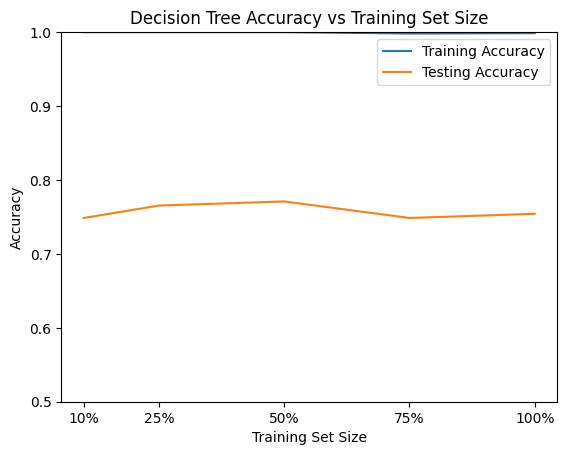

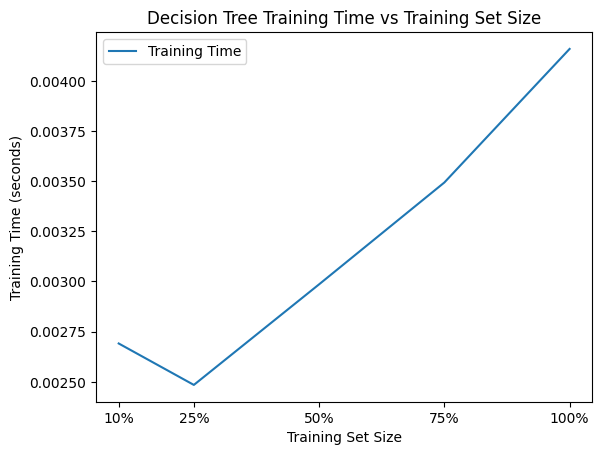

In [17]:
# Splits the training set into a subset of the original data
def split_training_set(features_train, labels_train, test_size):
    return train_test_split(
        features_train,
        labels_train,
        test_size= 1.0-test_size,
        random_state=42,
        stratify=labels_train
    )

# Split the training set into subsetes of the original data
features_train_10, _, labels_train_10, _ = split_training_set(features_train, labels_train, 0.1)
features_train_25, _, labels_train_25, _ = split_training_set(features_train, labels_train, 0.25)
features_train_50, _, labels_train_50, _ = split_training_set(features_train, labels_train, 0.5)
features_train_75, _, labels_train_75, _ = split_training_set(features_train, labels_train, 0.75)

train_times = []
training_accuracies = []
testing_accuracies = []

def test_tree(train_x, train_y):
    times = []
    # Get the average training time over 200 iterations
    for i in range(200):
        start = time.time()
        model = DecisionTreeClassifier(criterion='entropy', random_state=42).fit(train_x, train_y)
        end = time.time()
        times.append(end-start)
    # Print out the data
    average_time = sum(times)/len(times)
    print("Training time: ", average_time)
    training_accuracy = model.score(train_x, train_y)
    print("Training accuracy: ", training_accuracy)
    test_accuracy = model.score(features_test, labels_test)
    print("Testing accuracy: ", test_accuracy)
    # Append data to the list for plotting later
    train_times.append(average_time)
    training_accuracies.append(training_accuracy)
    testing_accuracies.append(test_accuracy)

# Record training and testing accuracies for each subset of the training data
print("Training model with 10% of the dataset")
test_tree(features_train_10, labels_train_10)
print()

print("Training model with 25% of the dataset")
test_tree(features_train_25, labels_train_25)
print()

print("Training model with 50% of the dataset")
test_tree(features_train_50, labels_train_50)
print()

print("Training model with 75% of the dataset")
test_tree(features_train_75, labels_train_75)
print()

print("Training model with 100% of the dataset")
test_tree(features_train, labels_train)
print()

train_set_size = [0.1, 0.25, 0.5, 0.75, 1]

# Plot training and testing accuracy vs training set size
pyplot.plot(train_set_size, training_accuracies, label='Training Accuracy')
pyplot.plot(train_set_size, testing_accuracies, label='Testing Accuracy')
pyplot.xlabel('Training Set Size')
pyplot.ylabel('Accuracy')
pyplot.ylim(0.5, 1)
pyplot.xticks(train_set_size, ['10%', '25%', '50%', '75%', '100%'])
pyplot.title('Decision Tree Accuracy vs Training Set Size')
pyplot.legend()
pyplot.show()

# Plot training time vs training set size
pyplot.plot(train_set_size, train_times, label='Training Time')
pyplot.xlabel('Training Set Size')
pyplot.ylabel('Training Time (seconds)')
pyplot.xticks(train_set_size, ['10%', '25%', '50%', '75%', '100%'])
pyplot.title('Decision Tree Training Time vs Training Set Size')
pyplot.legend()
pyplot.show()




2) In a markdown cell, analyze your plots. How does increasing training set size 
affect accuracy? Does the gap between training and testing accuracy shrink or grow? 
How does training time scale?  

The training set size seems to have very little effect on the accuracy of the model. As the training set size increased, the testing accuracy very slightly decreased and the testing accuracy mostly stayed the same. I think this is caused mostly due to the model overfitting on the training dataset so that the accuracy for the training data would always be very high. This would also explain the little change in accuracy over the training set sizes because the model isn't getting any better at predicting new data as the training set size increases. The gap between testing accuracy mostly stays the same. 

The training time has a positive correlation with the training set size, the larger the training data, the longer it takes on average to train. This is expected because the model has to do more calculations when given more data.

### Part 3: Tuning max_depth with 5-Fold Cross-Validation (CV) 

* #### Find the Best max_depth 

1. You will loop over candidate depth values and use cross_val_score() to 
evaluate each one. It returns an array of 5 accuracy scores, one per fold. Record both the 
mean and the standard deviation of those 5 scores for each depth. 

In [18]:
from sklearn.model_selection import cross_val_score
import numpy as np

# Loop over candidate depth values from 1 to 20
depth_range = range(1, 21)
cv_means = []
cv_stds = []
cv_times = []

for depth in depth_range:
    tree = DecisionTreeClassifier(criterion='entropy', random_state=42, max_depth=depth)
    start = time.time()
    scores = cross_val_score(tree, features_train, labels_train, cv=5, scoring='accuracy')
    end = time.time()
    cv_means.append(scores.mean())
    cv_stds.append(scores.std())
    cv_times.append(end - start)
    print(f"max_depth={depth:2d}  |  Mean CV Accuracy: {scores.mean():.4f}  |  Std: {scores.std():.4f}  |  Time: {end - start:.4f}s")


max_depth= 1  |  Mean CV Accuracy: 0.7262  |  Std: 0.0257  |  Time: 0.0578s
max_depth= 2  |  Mean CV Accuracy: 0.8287  |  Std: 0.0095  |  Time: 0.0424s
max_depth= 3  |  Mean CV Accuracy: 0.8244  |  Std: 0.0048  |  Time: 0.0357s
max_depth= 4  |  Mean CV Accuracy: 0.8286  |  Std: 0.0132  |  Time: 0.0337s
max_depth= 5  |  Mean CV Accuracy: 0.8230  |  Std: 0.0261  |  Time: 0.0427s
max_depth= 6  |  Mean CV Accuracy: 0.8103  |  Std: 0.0283  |  Time: 0.0637s
max_depth= 7  |  Mean CV Accuracy: 0.8300  |  Std: 0.0146  |  Time: 0.0515s
max_depth= 8  |  Mean CV Accuracy: 0.8131  |  Std: 0.0175  |  Time: 0.0526s
max_depth= 9  |  Mean CV Accuracy: 0.8202  |  Std: 0.0190  |  Time: 0.0530s
max_depth=10  |  Mean CV Accuracy: 0.8146  |  Std: 0.0220  |  Time: 0.0607s
max_depth=11  |  Mean CV Accuracy: 0.8048  |  Std: 0.0188  |  Time: 0.0505s
max_depth=12  |  Mean CV Accuracy: 0.7991  |  Std: 0.0126  |  Time: 0.0406s
max_depth=13  |  Mean CV Accuracy: 0.7935  |  Std: 0.0091  |  Time: 0.0565s
max_depth=14

2. Create a figure with two subplots (Label all axes, include titles, and add a 
legend where appropriate) 
    1) Subplot 1: Mean CV accuracy vs. max_depth with error bars representing the 
standard deviation.  
    2) Subplot 2: Cross-validation time vs. max_depth. 

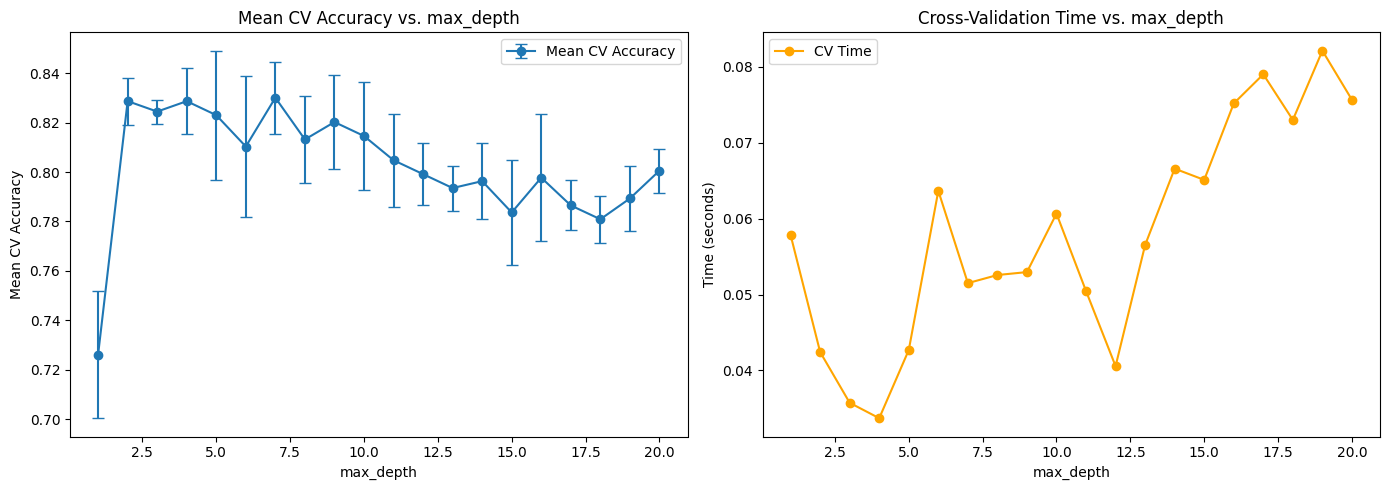

In [19]:
fig, (ax1, ax2) = pyplot.subplots(1, 2, figsize=(14, 5))

#plot 1: Mean CV accuracy with std error bars
ax1.errorbar(list(depth_range), cv_means, yerr=cv_stds, marker='o', capsize=4, label='Mean CV Accuracy')
ax1.set_xlabel('max_depth')
ax1.set_ylabel('Mean CV Accuracy')
ax1.set_title('Mean CV Accuracy vs. max_depth')
ax1.legend()



#plot 2: Cross-validation time
ax2.plot(list(depth_range), cv_times, marker='o', color='orange', label='CV Time')
ax2.set_xlabel('max_depth')
ax2.set_ylabel('Time (seconds)')
ax2.set_title('Cross-Validation Time vs. max_depth')
ax2.legend()

pyplot.tight_layout()
pyplot.show()


3. In a markdown cell, identify the best max_depth based on the highest mean 
CV accuracy. Then answer: 
    1) If multiple depths give very similar mean CV accuracy, which would you prefer 
and why? Consider both the mean and the standard deviation. 
    2) Print the best max_depth with its mean CV accuracy and standard deviation. 

In [20]:
best_index = np.argmax(cv_means)
best_depth = list(depth_range)[best_index]
best_mean = cv_means[best_index]
best_std = cv_stds[best_index]


print(f"Best max_depth: {best_depth}")
print(f"Mean CV Accuracy: {best_mean:.4f}")
print(f"Standard Deviation: {best_std:.4f}")


Best max_depth: 7
Mean CV Accuracy: 0.8300
Standard Deviation: 0.0146


If multiple depths give very similar mean CV accuracy, I would prefer the shallower tree with lower max_depth because it is simpler and less likely to overfit. A shallower tree also tends to have a lower std across folds, so it generalizes better. Between two models with nearly identical mean accuracy, the one with lower variance is the safer choice.

* #### Evaluate the Final Model on the Test Set 

1. Now that you have selected the best max_depth, retrain the final model on the 
full X_train and evaluate once on X_test. Report training accuracy and testing accuracy. 

In [21]:
#retrain with best max_depth on the full training set
tuned_start = time.time()
tuned_classifier = DecisionTreeClassifier(criterion='entropy', random_state=42, max_depth=best_depth).fit(features_train, labels_train)
tuned_time = time.time() - tuned_start

print(f"Tuned Model (max_depth={best_depth}):")
print(f"  Training Accuracy: {tuned_classifier.score(features_train, labels_train):.4f}")
print(f"  Testing Accuracy:  {tuned_classifier.score(features_test, labels_test):.4f}")


Tuned Model (max_depth=7):
  Training Accuracy: 0.8862
  Testing Accuracy:  0.7933


2) Generate and display confusion matrix for both tuned and untuned model 
(already generated in 2.3) on the test set. In a markdown cell, compare the confusion 
matrices. Did tuning max_depth reduce any specific type of error? 

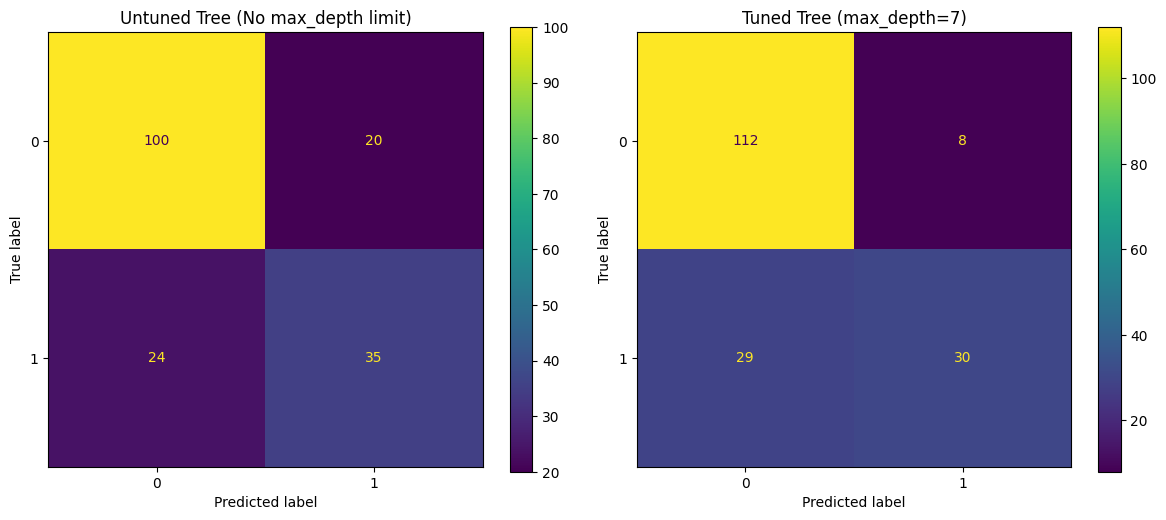

In [22]:
fig, (ax1, ax2) = pyplot.subplots(1, 2, figsize=(12, 5))

#untined
ConfusionMatrixDisplay.from_estimator(classifier, features_test, labels_test, ax=ax1)
ax1.set_title('Untuned Tree (No max_depth limit)')

#tuned
ConfusionMatrixDisplay.from_estimator(tuned_classifier, features_test, labels_test, ax=ax2)
ax2.set_title(f'Tuned Tree (max_depth={best_depth})')

pyplot.tight_layout()
pyplot.show()


Looking at the confusion matrices, the tuned improves in some areas: False positives decreased (20 -> 8) and true negatives increased (100 -> 112), suggesting the model became better at correctly identifying non-survivors. Although this came with trade-offs: false negatives increased (24 -> 29) and true positives decreased (35 -> 30), so the tuned model actually got slightly worse at identifying actual survivors. Overall, tuning max_depth helped reduce overfitting, but the improvement is not uniform across all metrics, it did shift the model's bias toward predicting non-survival more conservatively.

 3) Create a summary comparison table with columns: Max_depth | Mean CV Accuracy | Test Accuracy | Leaves | Time

In [23]:
untuned_start = time.time()
DecisionTreeClassifier(criterion='entropy', random_state=42).fit(features_train, labels_train)
untuned_time = time.time() - untuned_start

#table
summary = pandas.DataFrame({
    'Model': ['Untuned Tree', 'Tuned Tree'],
    'Max_depth': [classifier.get_depth(), best_depth],
    'Mean CV Accuracy': ['N/A', f'{best_mean:.4f}'],
    'Test Accuracy': [
        f'{classifier.score(features_test, labels_test):.4f}',
        f'{tuned_classifier.score(features_test, labels_test):.4f}'
    ],
    'Leaves': [classifier.get_n_leaves(), tuned_classifier.get_n_leaves()],
    'Time': [f'{untuned_time:.4f}s', f'{tuned_time:.4f}s']
})

print(summary.to_string(index=False))

       Model  Max_depth Mean CV Accuracy Test Accuracy  Leaves    Time
Untuned Tree         26              N/A        0.7542     130 0.0103s
  Tuned Tree          7           0.8300        0.7933      37 0.0071s


4. Comment on the differences: Did the tuned model reduce overfitting? How does the 
number of leaves compare? How close is the mean CV accuracy to the final test 
accuracy?

In [24]:
print("Comparison Analysis:")
print(f"  Untuned tree depth: {classifier.get_depth()}, Tuned tree depth: {best_depth}")
print(f"  Untuned tree leaves: {classifier.get_n_leaves()}, Tuned tree leaves: {tuned_classifier.get_n_leaves()}")
print(f"  Untuned test accuracy: {classifier.score(features_test, labels_test):.4f}")
print(f"  Tuned test accuracy:   {tuned_classifier.score(features_test, labels_test):.4f}")
print(f"  Mean CV accuracy:      {best_mean:.4f}")



Comparison Analysis:
  Untuned tree depth: 26, Tuned tree depth: 7
  Untuned tree leaves: 130, Tuned tree leaves: 37
  Untuned test accuracy: 0.7542
  Tuned test accuracy:   0.7933
  Mean CV accuracy:      0.8300


The tuned model significantly reduces overfitting. The untuned tree has way more leaves,
indicating it memorized the training data. The tuned model has far fewer leaves and a much
smaller gap between training and testing accuracy. The mean CV accuracy is close to the
final test accuracy, which confirms that cross-validation gave a reliable estimate of
generalization performance.


* ####  Visualize the Tuned Tree

1. Visualize your tuned and untuned decision trees. Set feature_names to your 
column names.  

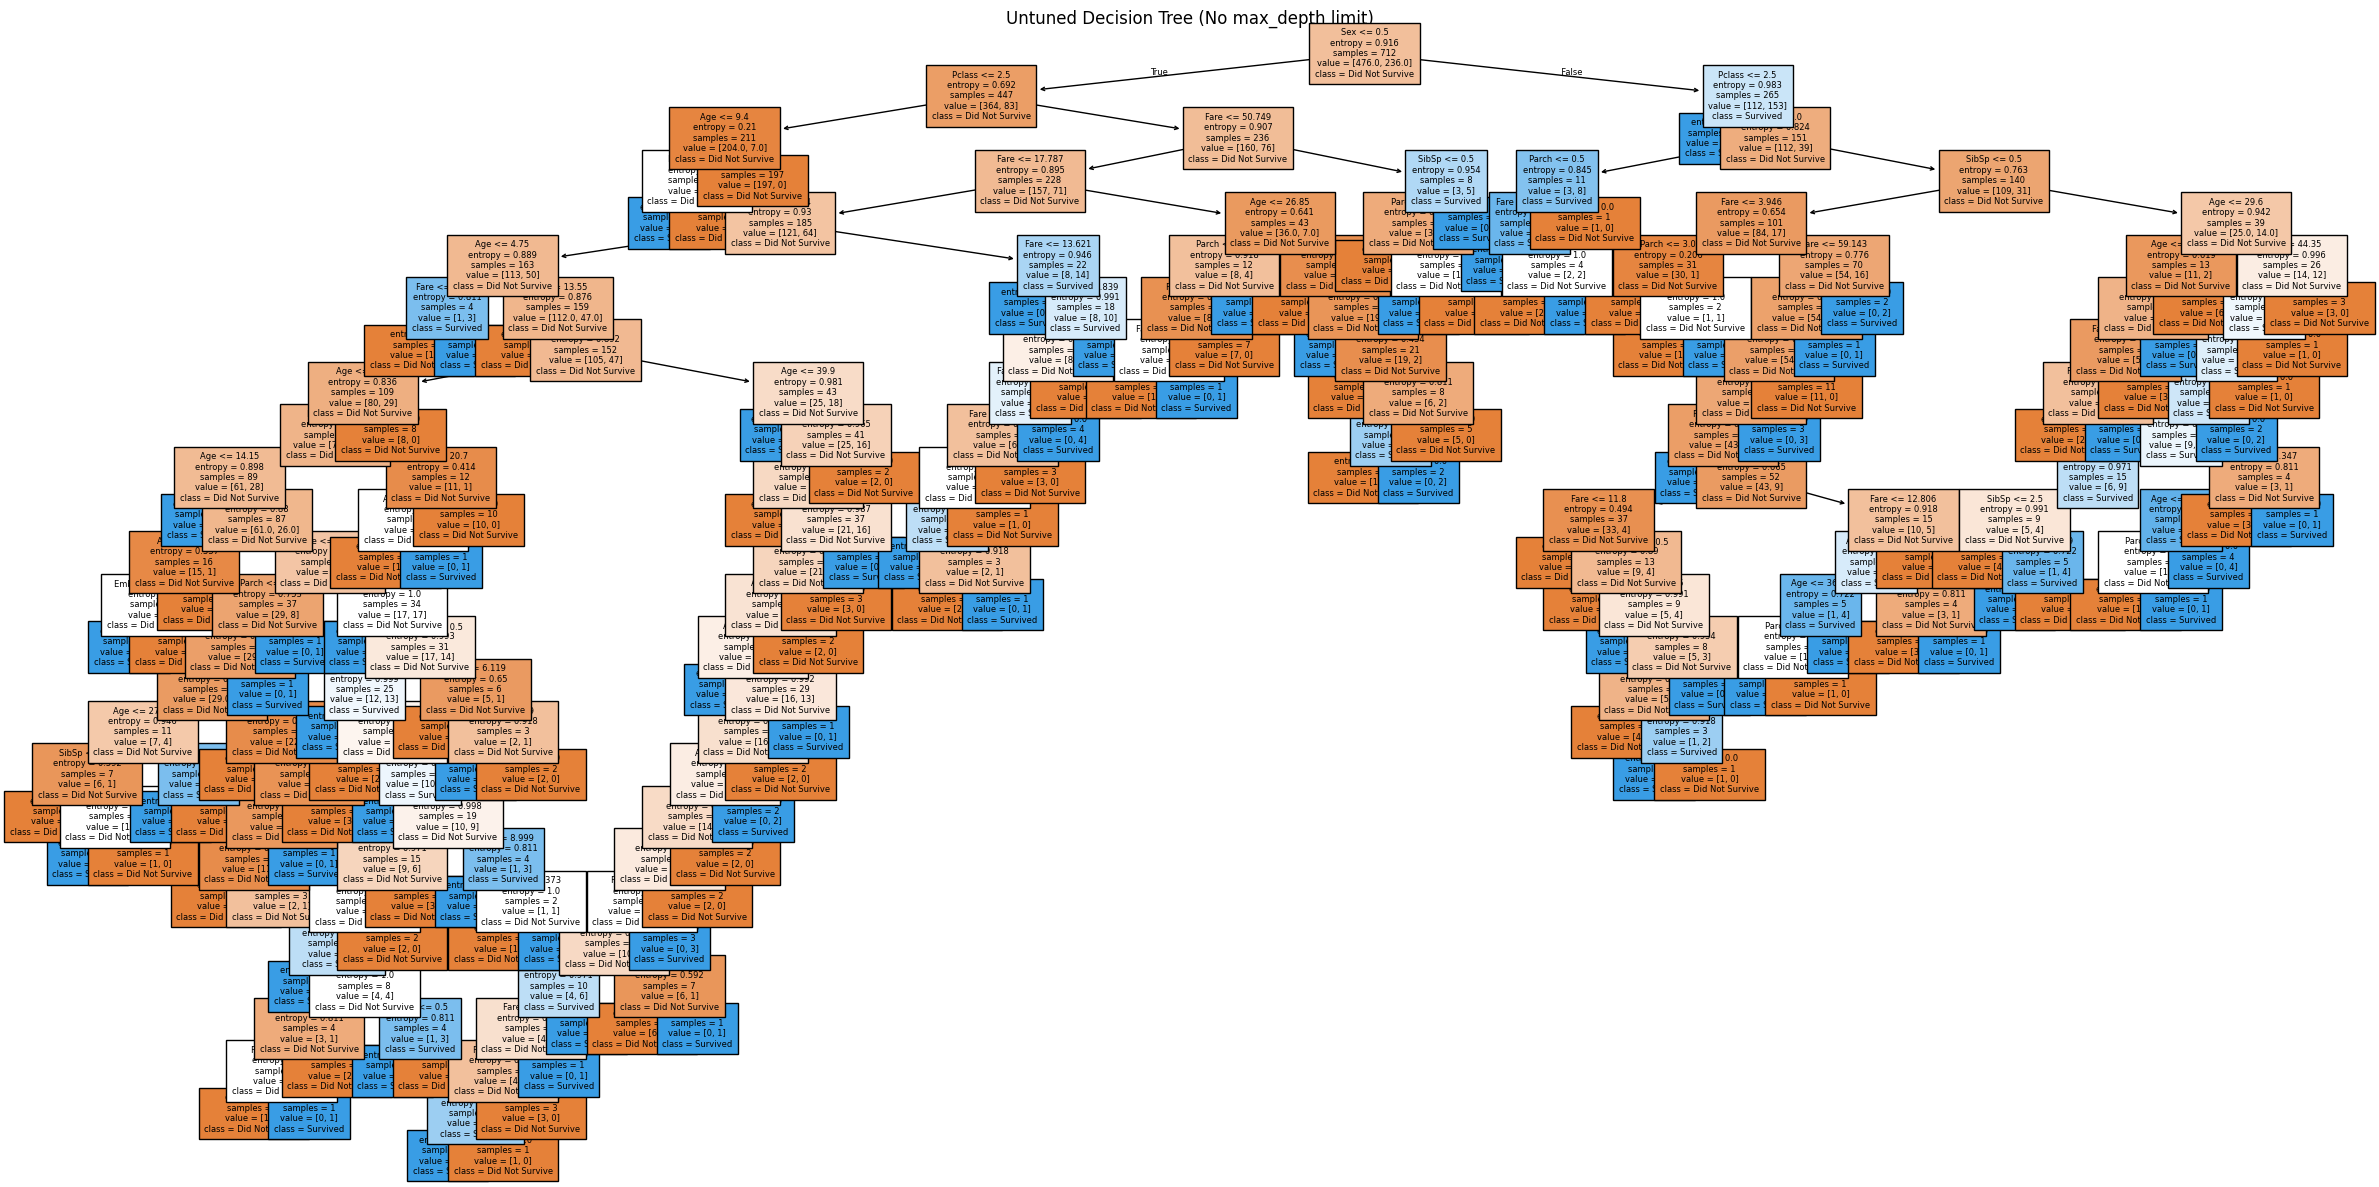

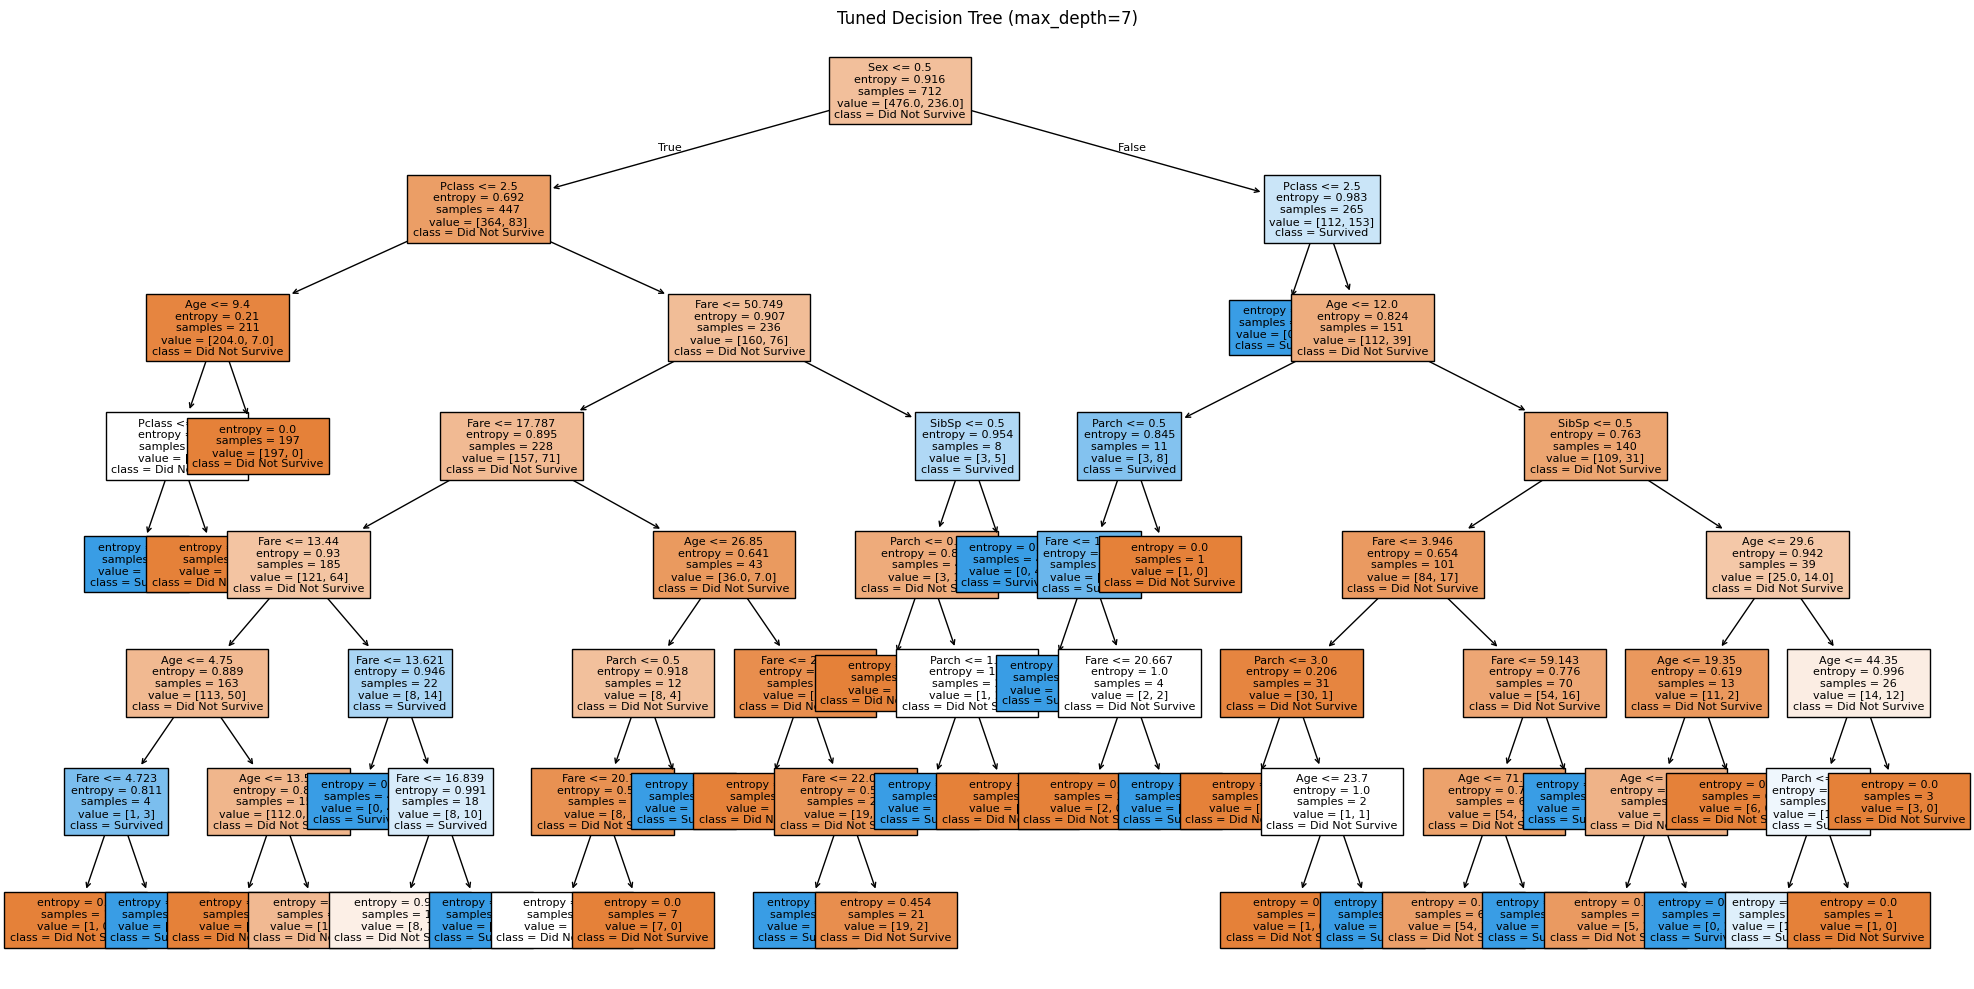

In [25]:
from sklearn.tree import plot_tree

#untuned tree
pyplot.figure(figsize=(24, 12))
plot_tree(classifier, feature_names=features.columns.tolist(), class_names=['Did Not Survive', 'Survived'], filled=True, fontsize=6)
pyplot.title('Untuned Decision Tree (No max_depth limit)')
pyplot.tight_layout()
pyplot.show()

#tuned tree
pyplot.figure(figsize=(20, 10))
plot_tree(tuned_classifier, feature_names=features.columns.tolist(), class_names=['Did Not Survive', 'Survived'], filled=True, fontsize=8)
pyplot.title(f'Tuned Decision Tree (max_depth={best_depth})')
pyplot.tight_layout()
pyplot.show()


## Contribution:

- Xander Boosinger
- Zach Rojas: Training and assessing the unpruned decision tree, analyze overfitting and the accuracy across different max_depth values, generate confusion matrix, and analyze the effect of training sample size on the model (Part 2)
- Kyle Nguyen: Cross-validation loop, best max_depth selection, tuned model evaluation, confusion matrix comparison, summary table, and tree visualizations (Part 3).

### AI Disclosure:

No AI was used for this assignment.